In [335]:
import pandas as pd

In [336]:
file_path = r'C:\Users\HP\Documents\Data Analytics\Build Portfolio\SPEN_Cutomer_Lifecycle\SPEN_Cus_Purchase_data.csv'

In [337]:
df = pd.read_csv(file_path)

# Data Cleaning

In [338]:
# Overwrite the dataframe with only the matching records
df = df[df['Status'] == 'Cash Remitted']

In [339]:
# remove unwanted columns form the dataset
df = df.drop(columns=['WhatsApp_Number', 'Address', 'Processed_By', 'Updated_By', 'Delivered_By', 'Email', 'Others', 'Comments', 'Name', 'Order_Type', 'Order_Id', 'Delivery_Fee'])

In [340]:
# correct double digit entiries in quantity colum
df.loc[df['Quantity'] > 10, 'Quantity'] = (df.loc[df['Quantity'] > 10, 'Quantity'] / 30).round()

In [341]:
# convert entires in foreign currency(Ghanaian Cedi & Kenyan Shilling) to local currency(Naira)

# List of product names to target
products_to_update = [
    'Clovon combo Tea & Spray',
    'Backease',
    'Ara Hair Care',
    'Clovon (GH)',
    'Clovon combo Ghana',
    'Teeth Whitener Ghana (Main)',
    'Teeth Whitener Ghana',
    'Scenty Ghana ex',
    'NAXA GHANA',
    'Clovon combo Tea GH'
]

# Create a mask for Ghana product
mask_ghana = df['Product'].isin(products_to_update)

# Multiply Cost Price and Selling Price by 127 for these products
df.loc[mask_ghana, 'Cost_Price'] = (df.loc[mask_ghana, 'Cost_Price'] * 127).round(2)
df.loc[mask_ghana, 'Selling_Price'] = (df.loc[mask_ghana, 'Selling_Price'] * 127).round(2)

# Create a mask for the Kenya product
mask_kenya = (df['Product'] == 'CC Tea & Spray Kenya')

# Multiply Cost Price and Selling Price by 11
df.loc[mask_kenya, 'Cost_Price'] = (df.loc[mask_kenya, 'Cost_Price'] * 11).round(2)
df.loc[mask_kenya, 'Selling_Price'] = (df.loc[mask_kenya, 'Selling_Price'] * 11).round(2)

In [342]:
# To handle the missing values

# for Quantity column, fill with mode (most common quantity) per product
df['Quantity'] = df.groupby('Product')['Quantity'].transform(
    lambda x: x.fillna(x.mode()[0])
)
# for Cost price column, fill with median cost price per product
df['Cost_Price'] = df.groupby('Product')['Cost_Price'].transform(
    lambda x: x.fillna(x.median())
)

# RFM Analysis

In [343]:
from datetime import datetime

In [344]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])


# to calculate Recency, use the day of most recent order
latest_date = df['Order_Date'].max()

# aggregate by Customer
rfm = df.groupby('Phone_Number_1').agg({
    'Order_Date': lambda x: (latest_date - x.max()).days, # Recency
    'Product': 'count',                                   # Frequency
    'Selling_Price': 'sum'                                # Monetary
})

# Rename columns for clarity
rfm.rename(columns={
    'Order_Date': 'Recency',
    'Product': 'Frequency',
    'Selling_Price': 'Monetary'
}, inplace=True)

In [345]:
# to assign RFM score Create 5-point scales using quantiles
# for recency lower days = better, so scoring is inverted
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Concatenate the scores into a single string (e.g., "555")
rfm['RFM_ID'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Feature Scaling

In [346]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Use only the RFM numeric columns for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

In [347]:
# scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# The Elbow Method

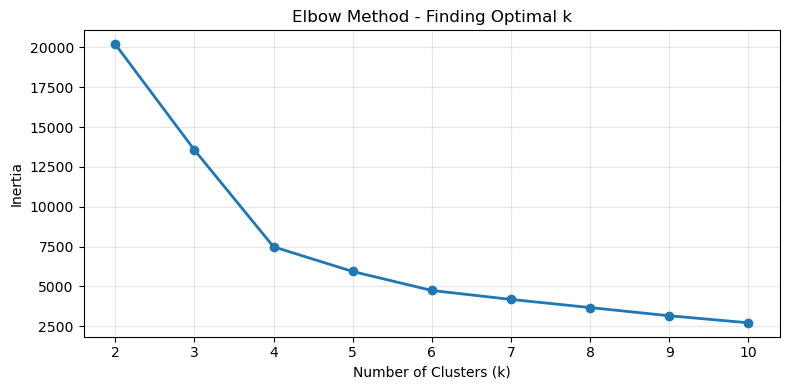

In [348]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k=2: Silhouette Score = 0.6113
k=3: Silhouette Score = 0.6041
k=4: Silhouette Score = 0.5302
k=5: Silhouette Score = 0.5413
k=6: Silhouette Score = 0.4494
k=7: Silhouette Score = 0.4464
k=8: Silhouette Score = 0.4464
k=9: Silhouette Score = 0.4156
k=10: Silhouette Score = 0.4220


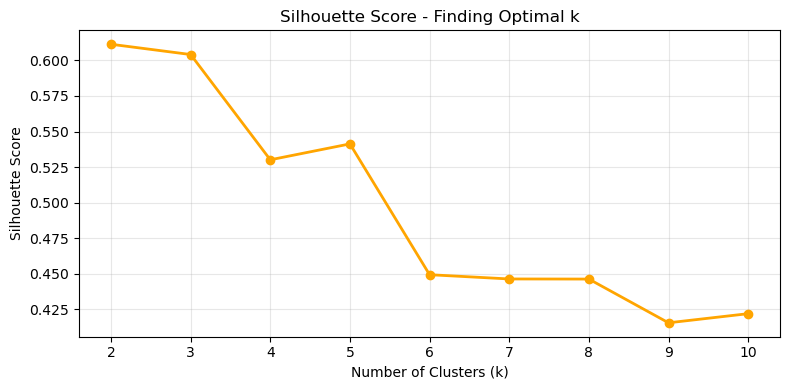

In [349]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k}: Silhouette Score = {score:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Finding Optimal k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fit the final model

In [350]:
# going against the elbow method, the silhouette coefficient suggest 2 clusters as the optimum K
optimal_k = 2

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [351]:
# Interpret the Clusters
cluster_summary = rfm.groupby('Cluster').agg(
    Customer_Count=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

print(cluster_summary)

         Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                          
0                   924       450.28           2.22      69841.97
1                  8313       434.20           1.00      30641.17


In [352]:
# assign labels
cluster_labels = {
    0: 'High Value',
    1: 'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

# Visualise the Clusters

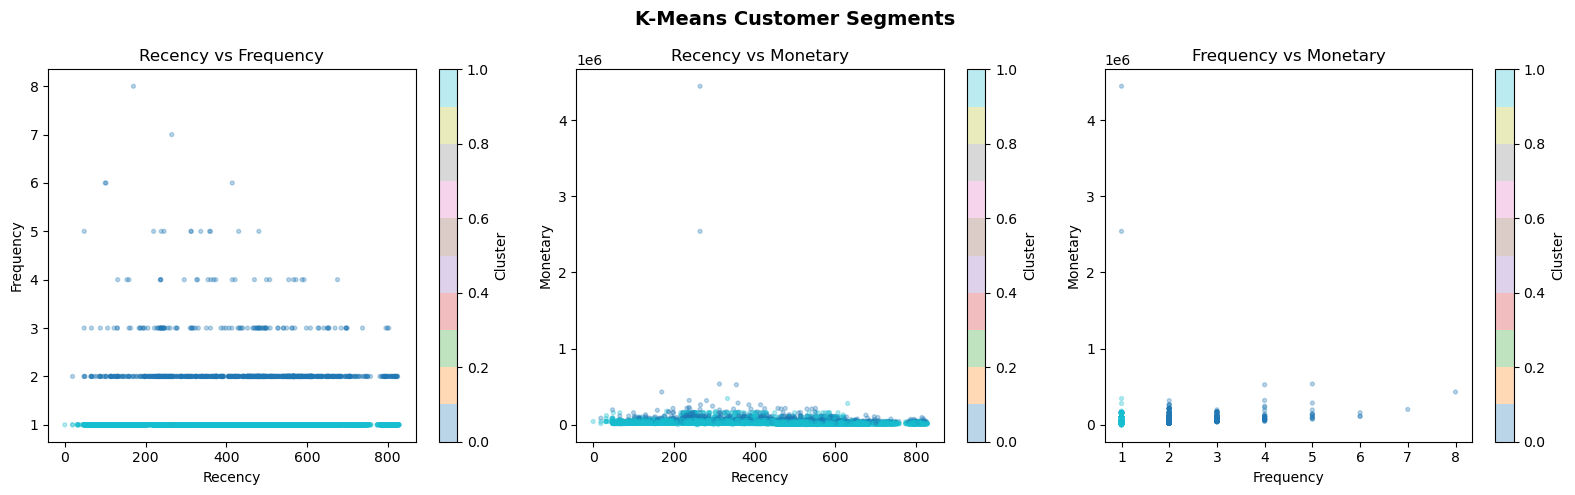

In [353]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('Recency', 'Frequency'),
    ('Recency', 'Monetary'),
    ('Frequency', 'Monetary')
]

for ax, (x, y) in zip(axes, pairs):
    scatter = ax.scatter(
        rfm[x], rfm[y],
        c=rfm['Cluster'],
        cmap='tab10',
        alpha=0.3,
        s=8
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('K-Means Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [354]:
# Export data as CSV
rfm.to_csv('rfm_segments.csv', index=False)